# Clinical Trial Enrichment Benchmark

Validates whether genetic evidence enriches progression through clinical
trial phases, using open data sources and compares with Citeline subset published by Minikel et al., 2024.

In [1]:
import logging
import shutil
import sys
import tempfile
import warnings
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter
from tidepool import set_mpl_style

from ct_validation import MissingOngoingWarning, forest_plot, validate
from ct_validation.validation.statistics import katz_ci_risk_ratio, woolf_ci_odds_ratio

# aggregate.py lives outside the package; imported so the per-source rebuilds below take
# its censoring rule rather than restating it.
sys.path.insert(0, str(Path("../scripts/parse/clinical_trials").resolve()))
import aggregate
import trial_status

# Every rebuild stages a subset, so `_load_sources` warns NOT FOUND for the legs left out.
logging.getLogger(aggregate.__name__).setLevel(logging.ERROR)

set_mpl_style()
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Inter", "Helvetica", "Arial", "DejaVu Sans"]
# Fixed salt for the element ids matplotlib otherwise derives per session; together with the
# timestamp savefig drops, it makes an unchanged figure re-render byte-identical.
plt.rcParams["svg.hashsalt"] = "ct-validation"

DATA = Path("../data")
GE_DIR = DATA / "genetic_evidence"
CT_DIR = DATA / "clinical_trials"

CLINICAL_TRIALS = CT_DIR / "aggregated" / "gene_indication_max_phase.parquet"
CT_UNKNOWN_ONGOING = CT_DIR / "aggregated_unknown_ongoing" / "gene_indication_max_phase.parquet"
GD_BY_SOURCE = CT_DIR / "aggregated" / "gene_drug_by_source.parquet"
DI_BY_SOURCE = CT_DIR / "aggregated" / "drug_indication_by_source.parquet"
OT_DATA = DATA / "sources" / "opentargets" / "25.12"
OT_TARGET = OT_DATA / "target"
SIMILARITY = DATA / "mappings" / "efo_similarity_lookup_0.5.parquet"
GENE_UNIVERSE = DATA / "mappings" / "protein_coding_genes.txt"
DGIDB_DRUGS = DATA / "sources" / "dgidb" / "drugs.tsv.gz"

GE_OPENTARGETS = GE_DIR / "opentargets.parquet"
GE_SOURCES = {
    "GWAS Catalog": GE_DIR / "gwas_catalog.parquet",
    "ClinVar": GE_DIR / "clinvar.parquet",
    "OpenTargets": GE_OPENTARGETS,
    "Genebass": GE_DIR / "genebass.parquet",
}
GE_COMBINED = GE_DIR / "aggregated" / "genetic_evidence.parquet"
# Somatic datasources added back, for the scope sensitivity at the end of §3.
GE_OPENTARGETS_SOMATIC = GE_DIR / "opentargets_with_somatic.parquet"
GE_COMBINED_SOMATIC = GE_DIR / "aggregated" / "genetic_evidence_with_somatic.parquet"

MINIKEL_DIR = DATA / "minikel"
# Open Targets as a standalone provider: `known_drug` as released, not the aggregate.
OT_KNOWN_DRUG = OT_DATA / "known_drug"

VALIDATE_KWARGS = dict(similarity_lookup=SIMILARITY, gene_universe=GENE_UNIVERSE)

OUTPUT = Path("output")
OUTPUT.mkdir(exist_ok=True)
FIGS = OUTPUT / "figures"
FIGS.mkdir(exist_ok=True)

PHASE_ORDER = ["I→II", "II→III", "III→Approved", "I→Approved"]
# Display name -> the `<prefix>_<leg>.parquet` stem `aggregate.py` discovers sources by.
CT_GD_SOURCES = {
    "ChEMBL": "chembl",
    "DGIdb": "dgidb",
    "STITCH": "stitch",
    "OpenTargets": "opentargets",
    "TrialPanorama": "trialpanorama",
}
# ChEMBL is absent here on purpose: its indications carry no trial status, so the
# aggregate excludes them (DRUG_INDICATION_EXCLUDED_SOURCES). It stays in CT_GD_SOURCES.
CT_DI_SOURCES = {"OpenTargets": "opentargets", "TrialPanorama": "trialpanorama"}

In [2]:
def run_multi(
    experiments: dict[str, tuple], label_col="experiment", *, bootstrap=False, cluster_col="gene"
):
    """Run validate() for multiple (targets, clinical_trials) pairs.

    `bootstrap` adds clustered CIs for both ratios, resampling `cluster_col`. Off by default:
    it costs a resampling pass per transition, and only the headline design of §2 is asked to
    defend its intervals against one gene spanning many indications.
    """
    results = []
    for name, (ge, ct) in experiments.items():
        r = validate(
            clinical_trials=ct,
            targets=ge,
            cluster_col=cluster_col if bootstrap else None,
            **VALIDATE_KWARGS,
        )
        r[label_col] = name
        results.append(r)
    return pd.concat(results, ignore_index=True)


def filter_ct_by(ct: pd.DataFrame, column: str, source: str) -> pd.DataFrame:
    """Filter CT to rows where column contains source, keep validate() schema.

    Selects the pairs a source *contributed to*, not its phases: `max_phase` in the collapsed
    table is the maximum over every source that reported the pair. When the phases have to
    be a single source's own, rebuild from that source's own tables instead —
    `known_drug_pairs` does it for Open Targets.
    """
    return ct[ct[column].str.contains(source, na=False)][
        ["gene", "efo_id", "max_phase", "is_ongoing"]
    ]


def rebuild_ct(gene_drug: list[str], drug_indication: list[str]) -> pd.DataFrame:
    """Re-run the aggregation over one subset of source legs, in a scratch directory.

    `aggregate.py` discovers the two legs independently by file presence, so staging
    `<src>_gene_drug.parquet` and `<src>_drug_indication.parquet` separately gives a table
    whose genes come from one set of sources and whose phases come from another. Rebuilding
    also rebuilds the drug clustering, so an arm carries no unstaged source's drug identity
    — which filtering the collapsed table cannot give you.

    DGIdb's synonym table is passed only when DGIdb is on the gene-drug leg. Its synonyms
    bridge drug clusters, so handing them to an arm without DGIdb would leak it back in.
    """
    with tempfile.TemporaryDirectory() as tmp:
        work, out = Path(tmp) / "source", Path(tmp) / "aggregated"
        work.mkdir()
        for leg, sources in (("gene_drug", gene_drug), ("drug_indication", drug_indication)):
            for src in sources:
                parquet = CT_DIR / f"{src}_{leg}.parquet"
                # A misspelled source would otherwise stage nothing and silently return a
                # table built from the remaining legs, under this arm's label.
                if not parquet.exists():
                    raise FileNotFoundError(f"no {leg} file for source {src!r} in {CT_DIR}")
                shutil.copy(parquet, work / parquet.name)
        aggregate.aggregate_clinical_trials(
            work,
            out,
            dgidb_drugs_path=DGIDB_DRUGS if "dgidb" in gene_drug else None,
        )
        return pd.read_parquet(out / "gene_indication_max_phase.parquet")


def known_drug_pairs(*, censor: bool = True) -> pd.DataFrame:
    """Target-indication pairs straight from Open Targets `known_drug`.

    Group by target and disease, keep the maximum clinical phase and drop anything at or
    below phase 0.5. No drug clustering and no second source, so a gene carries only the
    phases Open Targets records against that indication. Symbols come from the table's own
    `approvedSymbol`, which matches the target index on every row; two are shared by X/Y
    pseudoautosomal targets, which the grouping collapses.

    The table carries per-trial `status`, so `is_ongoing` is derived from it with the same
    maps the Open Targets parser uses. Pass `censor=False` for the prior art's construction,
    which reads every record as concluded and drops none.
    """
    with duckdb.connect() as con:
        # sql
        rows = con.sql(
            f"""
            SELECT approvedSymbol AS gene,
                   -- First underscore only, matching the GE side these pairs join against.
                   regexp_replace(diseaseId, '_', ':') AS efo_id,
                   CAST(phase AS INTEGER) AS phase,
                   status
            FROM read_parquet('{OT_KNOWN_DRUG / "*.parquet"}')
            WHERE phase > 0.5
            """,
        ).fetchdf()

        if not censor:
            return (
                rows.groupby(["gene", "efo_id"], as_index=False)["phase"]
                .max()
                .rename(
                    columns={"phase": "max_phase"},
                )
            )

        rows = trial_status.apply(
            rows,
            trial_status.OPENTARGETS_CONCLUDED,
            trial_status.OPENTARGETS_DROPPED,
        )
        # `fillna(True)` mirrors aggregate.py's `COALESCE(is_concluded, TRUE)` — an unknown
        # status is read as concluded there, and the two spellings must not drift.
        con.register(
            "kd",
            rows.assign(
                phase_concluded=rows["phase"].where(rows["is_concluded"].fillna(value=True)),
            ),
        )
        # sql
        return con.sql(
            f"""
            SELECT gene, efo_id,
                   CAST(max(phase) AS INTEGER) AS max_phase,
                   {aggregate.is_ongoing_sql()} AS is_ongoing
            FROM kd
            GROUP BY 1, 2
            """,
        ).fetchdf()


def savefig(fig, name):
    """Save figure as both SVG and PNG."""
    fig.savefig(FIGS / f"{name}.svg", bbox_inches="tight", metadata={"Date": None})
    fig.savefig(FIGS / f"{name}.png", bbox_inches="tight", dpi=300)

## 1. Load Minikel (Citeline) data

Both files come from `scripts/parse/minikel.py` (MeSH-to-EFO remapping, Citeline
phase offset, censoring flag).

In [3]:
minikel_ct = pd.read_parquet(MINIKEL_DIR / "minikel_clinical_trials.parquet")
minikel_ge = pd.read_parquet(MINIKEL_DIR / "minikel_genetic_evidence.parquet")[["gene", "efo_id"]]

print(f"Minikel CT: {len(minikel_ct):,} pairs, {minikel_ct['gene'].nunique():,} genes")
print(f"Minikel GE: {len(minikel_ge):,} pairs, {minikel_ge['gene'].nunique():,} genes")

Minikel CT: 43,962 pairs, 2,462 genes
Minikel GE: 107,365 pairs, 12,523 genes


## 2. 3x3 comparison: provider x leg

Both legs from each of three providers, all nine combinations. Open Targets GE is a
subset of Combined GE; Open Targets CT is one of the five sources Combined CT unions.

|                   | Citeline CT | Open Targets CT | Combined CT     |
|-------------------|-------------|-----------------|-----------------|
| Minikel et al. GE | Replication |                 | Open CT quality |
| Combined GE       | GE quality  |                 | Headline        |
| Open Targets GE   |             |                 |                 |

In [4]:
ct_ot_only = known_drug_pairs()

GE_ARMS = {
    "Minikel et al. GE": minikel_ge,
    "Combined GE": GE_COMBINED,
    "Open Targets GE": GE_OPENTARGETS,
}
CT_ARMS = {
    "Citeline": minikel_ct,
    "Open Targets CT": ct_ot_only,
    "Combined CT": CLINICAL_TRIALS,
}
# Blocked by trial table: the forest plot reads as three groups of three.
comparison = {
    f"{ge_name} × {ct_name}": (ge, ct)
    for ct_name, ct in CT_ARMS.items()
    for ge_name, ge in GE_ARMS.items()
}
comparison_3x3 = run_multi(comparison, bootstrap=True)

# Sanity check: compare our EFO replication against Minikel's published MESH results.
# Their published values are censored too, so the three adjacent transitions are directly
# comparable; I→Approved is not, because they censor only at the I→II gate.
minikel_published = pd.read_parquet(
    MINIKEL_DIR / "minikel_enrichment_results.parquet",
)
minikel_published = minikel_published[minikel_published["area"] == "all"]
our_replication = comparison_3x3[comparison_3x3["experiment"] == "Minikel et al. GE × Citeline"]

phase_map = {"I": "I→II", "II": "II→III", "III": "III→Approved", "I-Launch": "I→Approved"}
print(f"{'Phase':<15} {'Minikel (MESH)':>15} {'Ours (EFO)':>12} {'Gap':>8}")
for _, row in minikel_published.iterrows():
    label = phase_map.get(row["phase"])
    if label is None:
        continue
    our = our_replication[our_replication["phase_label"] == label].iloc[0]
    gap = abs(our["rr"] - row["rs"]) / row["rs"]
    note = "*" if label == "I→Approved" else ""
    print(f"{label:<15} {row['rs']:>15.3f} {our['rr']:>12.3f} {gap:>7.1%}{note}")
print("* different estimators — theirs censors at the I→II gate only")

Phase            Minikel (MESH)   Ours (EFO)      Gap
I→II                      1.076        1.076    0.0%
II→III                    1.571        1.593    1.4%
III→Approved              1.275        1.260    1.2%
I→Approved                2.632        2.625    0.3%*
* different estimators — theirs censors at the I→II gate only


### Censoring sensitivity

All three clinical trial tables carry `is_ongoing`, so every arm above censors pairs whose
highest phase is still running. Dropping the column is the submitted manuscript's
convention; the rerun below covers all nine cells.

What feeds that column is a second choice. Open Targets `Unknown status` and TrialPanorama
`UNKNOWN` read as concluded by default, or as still running under
`aggregate.py --unknown-ongoing`.

In [5]:
def uncensored(ct):
    """Same clinical trials without the censoring column."""
    cols = ["gene", "efo_id", "max_phase"]
    return pd.read_parquet(ct, columns=cols) if isinstance(ct, Path) else ct[cols]


with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=MissingOngoingWarning)
    comparison_3x3_uncensored = run_multi(
        {name: (ge, uncensored(ct)) for name, (ge, ct) in comparison.items()},
        bootstrap=True,
    )

In [6]:
status_sensitivity = run_multi(
    {
        "Unknown as concluded (default)": (GE_COMBINED, CLINICAL_TRIALS),
        "Unknown as still running": (GE_COMBINED, CT_UNKNOWN_ONGOING),
    },
    label_col="unknown_status",
)
status_sensitivity.to_csv(OUTPUT / "status_sensitivity.csv", index=False)
print(
    status_sensitivity.pivot_table(index="phase_label", columns="unknown_status", values="rr")
    .loc[PHASE_ORDER]
    .assign(move=lambda d: d.iloc[:, 1] / d.iloc[:, 0] - 1)
    .round(4)
    .to_string(),
)

unknown_status  Unknown as concluded (default)  Unknown as still running    move
phase_label                                                                     
I→II                                    1.0356                    1.0354 -0.0002
II→III                                  1.1780                    1.1634 -0.0123
III→Approved                            1.2122                    1.1852 -0.0223
I→Approved                              1.5197                    1.4884 -0.0206


### Censoring conventions for the I→Approved span

Three conventions on the replication arm (Minikel et al. GE against Citeline): Tsepilov et al.
censor nothing, Minikel et al. censor at the entry gate only (their I→Launch denominator is
the phase I cohort), this work censors per transition.

In [7]:
conventions = {
    "no censoring (Tsepilov et al.)": uncensored(minikel_ct),
    "entry gate only (Minikel et al.)": minikel_ct.assign(
        is_ongoing=minikel_ct["is_ongoing"] & (minikel_ct["max_phase"] < 2),
    ),
    "per transition (this work)": minikel_ct,
}
censoring_conventions = run_multi(
    {name: (minikel_ge, ct) for name, ct in conventions.items()},
    label_col="censoring",
)
censoring_conventions.to_csv(OUTPUT / "censoring_conventions.csv", index=False)
print(
    censoring_conventions[censoring_conventions["phase_label"] == "I→Approved"][
        ["censoring", "n_yes", "n_no", "rr", "rr_ci_lower", "rr_ci_upper"]
    ].to_string(index=False),
)

/tmp/ipykernel_4152546/1569040639.py:12: MissingOngoingWarning: clinical_trials has no 'is_ongoing' column, so nothing is censored and a pair still in progress counts as a failure. Silence this with warnings.filterwarnings('ignore', category=MissingOngoingWarning).
  r = validate(


                       censoring  n_yes  n_no       rr  rr_ci_lower  rr_ci_upper
  no censoring (Tsepilov et al.)   1031 23144 2.821347     2.531213     3.144737
entry gate only (Minikel et al.)    924 20010 2.721773     2.447082     3.027298
      per transition (this work)    660 13785 2.625062     2.380440     2.894822


/tmp/ipykernel_4152546/3435242106.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


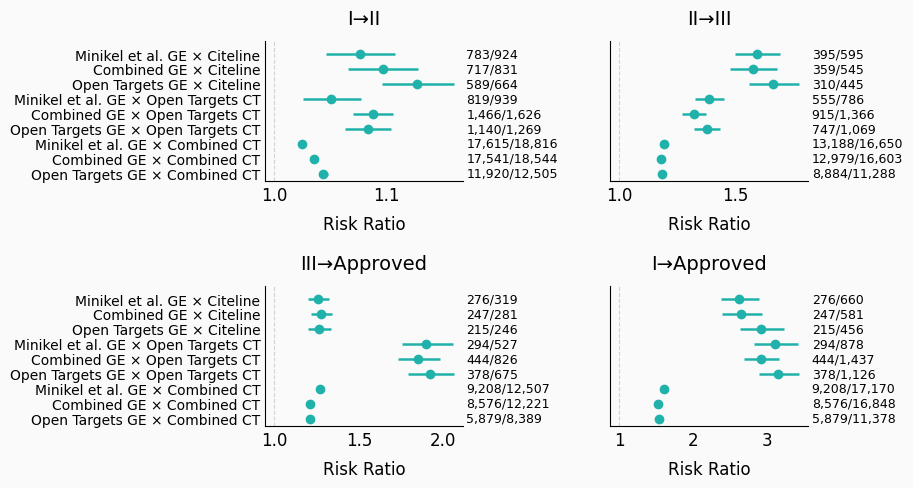

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(7, 5), gridspec_kw={"wspace": 0.75, "hspace": 0.75})
for ax, phase in zip(flat_ax := axes.flatten(), PHASE_ORDER):
    forest_plot(
        comparison_3x3,
        label_col="experiment",
        phase=phase,
        title=phase,
        ax=ax,
        sort_order=list(comparison.keys())[::-1],
    )
    if ax in (flat_ax[1], flat_ax[3]):
        ax.set_yticklabels([])
    ax.tick_params(axis="y", labelsize=10)
    # ax.texts is just forest_plot's count annotations, hardcoded there at 10.
    for txt in ax.texts:
        txt.set_fontsize(9)
    ax.set_ylim(-0.5, ax.get_ylim()[1] + 0.5)
fig.tight_layout()
savefig(fig, "1d_3x3_all_phases")

### Contingency counts behind each cell

Both censoring conventions in one table, in `validate()`'s own columns: of `n_yes` supported
pairs `x_yes` advanced, of `n_no` unsupported `x_no` did — for every cell of the 3x3 design
and every transition, with both effect measures and their intervals.

In [9]:
comparison_3x3_both = pd.concat(
    [
        comparison_3x3.assign(censoring="censored"),
        comparison_3x3_uncensored.assign(censoring="uncensored"),
    ],
    ignore_index=True,
)
comparison_3x3_both.to_csv(OUTPUT / "comparison_3x3.csv", index=False)

### Which unit carries the correlation

The clustered intervals above resample genes, on the argument that one gene spans many
indications. Indication is the competing candidate, and the stronger one here: an outcome is
the maximum phase of a drug, so two rows under different genes driven by the same
drug-indication carry the same outcome, which resampling genes cannot see.

Both arms below are the headline configuration, differing only in what is resampled.

In [10]:
cluster_sensitivity = pd.concat(
    [
        run_multi(
            {"Combined GE × Combined CT": (GE_COMBINED, CLINICAL_TRIALS)},
            bootstrap=True,
            cluster_col=col,
        ).assign(cluster=col)
        for col in ("gene", "efo_id")
    ],
    ignore_index=True,
)
cluster_sensitivity.to_csv(OUTPUT / "cluster_sensitivity.csv", index=False)

# Widening against the Katz interval each bootstrap is asked to correct, on the log scale.
print(
    cluster_sensitivity.assign(
        katz=lambda d: np.log(d["rr_ci_upper"] / d["rr_ci_lower"]),
        boot=lambda d: np.log(d["rr_boot_ci_upper"] / d["rr_boot_ci_lower"]),
    )
    .assign(widening=lambda d: d["boot"] / d["katz"])
    .pivot_table(
        index="phase_label",
        columns="cluster",
        values=["rr_boot_ci_lower", "rr_boot_ci_upper", "widening"],
    )
    .round(4)
    .to_string(),
)

             rr_boot_ci_lower         rr_boot_ci_upper         widening        
cluster                efo_id    gene           efo_id    gene   efo_id    gene
phase_label                                                                    
III→Approved           1.1704  1.1870           1.2516  1.2369   2.8738  1.7634
II→III                 1.1527  1.1612           1.2016  1.1942   2.5628  1.7261
I→Approved             1.4443  1.4726           1.5936  1.5677   3.2853  2.0902
I→II                   1.0280  1.0309           1.0427  1.0403   2.0362  1.3173


## 3. Per genetic evidence source

Each GE source separately, against the three trial tables of §2.

In [11]:
GE_VS_CT = {
    "Citeline CT": minikel_ct,
    "Open Targets CT": ct_ot_only,
    "Combined CT": CLINICAL_TRIALS,
}

ge_results = []
for ct_name, ct in GE_VS_CT.items():
    for name, result in zip(
        GE_SOURCES,
        validate(clinical_trials=ct, targets=list(GE_SOURCES.values()), **VALIDATE_KWARGS),
    ):
        ge_results.append(result.assign(source=name, ct=ct_name))

ge_comparison = pd.concat(ge_results, ignore_index=True)
ge_comparison.to_csv(OUTPUT / "ge_source_comparison.csv", index=False)

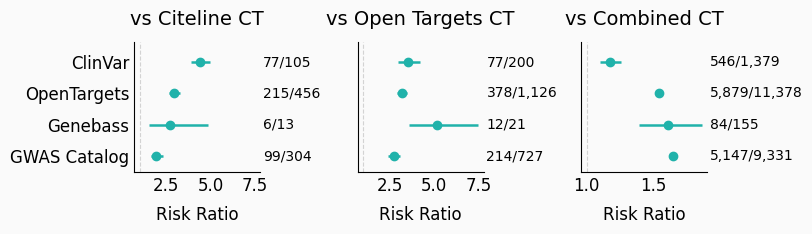

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(8.3, 2.5), sharey=True)
order = None
for ax, ct_name in zip(axes, GE_VS_CT):
    forest_plot(
        ge_comparison[ge_comparison["ct"] == ct_name],
        "source",
        "I→Approved",
        title=f"vs {ct_name}",
        ax=ax,
        sort_order=order,
    )
    # Row order is set by the first panel and shared by the other two.
    order = order or [t.get_text() for t in ax.get_yticklabels()]
axes[0].sharex(axes[1])
axes[0].set_ylim(-0.5, axes[0].get_ylim()[1] + 0.5)
fig.tight_layout()
savefig(fig, "1c_ge_sources")

### Somatic evidence scope

`eva_somatic` and `intogen` are somatic mutations in tumours, not germline support for a
target, so they are out of the headline — Minikel et al. limit themselves to germline
evidence too. `--include-somatic` puts them back, once for Open Targets alone, which is the
only source carrying them, and once for the aggregate it feeds. Against all three trial
tables of §2, so the Citeline leg says what the choice costs on Minikel's own data.

The aggregate arm restores Open Targets' two datasources only — ClinVar keeps its own
exclusion, a composite `somatic|susceptibility|response` condition filter with no somatic
toggle to flip, and GWAS Catalog and Genebass are germline by construction.

In [13]:
SOMATIC_SCOPE = {
    "Open Targets, germline": GE_OPENTARGETS,
    "Open Targets, with somatic": GE_OPENTARGETS_SOMATIC,
    "Combined, germline (headline)": GE_COMBINED,
    "Combined, + OT somatic": GE_COMBINED_SOMATIC,
}

somatic_scope = pd.concat(
    [
        run_multi(
            {name: (ge, ct) for name, ge in SOMATIC_SCOPE.items()},
            label_col="evidence_scope",
        ).assign(ct=ct_name)
        for ct_name, ct in GE_VS_CT.items()
    ],
    ignore_index=True,
)
somatic_scope.to_csv(OUTPUT / "somatic_scope.csv", index=False)

rr = somatic_scope[somatic_scope["phase_label"] == "I→Approved"].pivot_table(
    index="ct",
    columns="evidence_scope",
    values="rr",
)
print("I→Approved\n")
print(
    rr.loc[list(GE_VS_CT)][list(SOMATIC_SCOPE)]
    .assign(
        ot_move=lambda d: d["Open Targets, with somatic"] / d["Open Targets, germline"] - 1,
        combined_move=lambda d: d["Combined, + OT somatic"] / d["Combined, germline (headline)"]
        - 1,
    )
    .round(4)
    .to_string(),
)

I→Approved

evidence_scope   Open Targets, germline  Open Targets, with somatic  Combined, germline (headline)  Combined, + OT somatic  ot_move  combined_move
ct                                                                                                                                                
Citeline CT                      2.9223                      2.9387                         2.6490                  2.6842   0.0056         0.0133
Open Targets CT                  3.1563                      2.9936                         2.9216                  2.8174  -0.0515        -0.0357
Combined CT                      1.5405                      1.4577                         1.5197                  1.4660  -0.0537        -0.0354


## 4. Per clinical trial source

One leg varied a source at a time, the other held at every source. Each arm is a full
re-aggregation, so its phases and its drug clustering are the staged sources' own.
`All` is the shipped aggregate and anchors both panels.

ChEMBL, DGIdb and STITCH carry no indications, so they cannot build a table alone — the
gene-drug panel holds the indication leg fixed by necessity.

In [14]:
# Bound rather than inlined so §5 can profile them: holding seven arms resident costs memory
# through the rest of the notebook, which is still cheaper than re-aggregating each one.
CT_GD_ARMS = {
    name: rebuild_ct([prefix], list(CT_DI_SOURCES.values()))
    for name, prefix in CT_GD_SOURCES.items()
}
CT_DI_ARMS = {
    name: rebuild_ct(list(CT_GD_SOURCES.values()), [prefix])
    for name, prefix in CT_DI_SOURCES.items()
}

gd_comparison = run_multi(
    {
        **{name: (GE_COMBINED, ct) for name, ct in CT_GD_ARMS.items()},
        "All": (GE_COMBINED, CLINICAL_TRIALS),
    },
    label_col="source",
)
gd_comparison["ct_dimension"] = "gene_drug"

di_comparison = run_multi(
    {
        **{name: (GE_COMBINED, ct) for name, ct in CT_DI_ARMS.items()},
        "All": (GE_COMBINED, CLINICAL_TRIALS),
    },
    label_col="source",
)
di_comparison["ct_dimension"] = "drug_indication"

ct_comparison = pd.concat([gd_comparison, di_comparison], ignore_index=True)
ct_comparison.to_csv(OUTPUT / "ct_source_comparison.csv", index=False)
print(
    ct_comparison[ct_comparison["phase_label"] == "I→Approved"][
        ["ct_dimension", "source", "n_yes", "n_no", "rate_no", "rr", "rr_ci_lower", "rr_ci_upper"]
    ]
    .round(4)
    .to_string(index=False),
)

   ct_dimension        source  n_yes    n_no  rate_no     rr  rr_ci_lower  rr_ci_upper
      gene_drug        ChEMBL   1845  195218   0.2312 1.6718       1.5775       1.7717
      gene_drug         DGIdb  13308 1264134   0.3204 1.5677       1.5411       1.5948
      gene_drug        STITCH   6923  749483   0.3431 1.4709       1.4367       1.5059
      gene_drug   OpenTargets   2545  187849   0.2916 1.5511       1.4854       1.6198
      gene_drug TrialPanorama   1560  148353   0.2436 1.6999       1.6014       1.8044
      gene_drug           All  16848 1860161   0.3349 1.5197       1.4971       1.5426
drug_indication   OpenTargets   8973  549173   0.1392 2.0883       2.0206       2.1584
drug_indication TrialPanorama  13521 1587644   0.3615 1.5499       1.5267       1.5734
drug_indication           All  16848 1860161   0.3349 1.5197       1.4971       1.5426


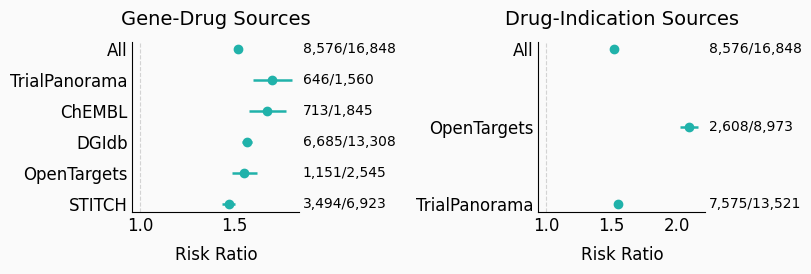

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.3, 2.9))
for ax, panel, title in (
    (ax1, gd_comparison, "Gene-Drug Sources"),
    (ax2, di_comparison, "Drug-Indication Sources"),
):
    by_rr = panel[panel["phase_label"] == "I→Approved"].sort_values("rr")["source"].tolist()
    forest_plot(
        panel,
        "source",
        "I→Approved",
        title=title,
        ax=ax,
        # `All` pinned to the bottom as the anchor, the rest by effect size.
        sort_order=[*(s for s in by_rr if s != "All"), "All"],
    )
fig.tight_layout()
savefig(fig, "s3_ct_sources")

## 5. Coverage and per-source composition

Three tables, each in its own units: the size of every table a benchmark arm runs on, what
each clinical-trial source holds on its own leg, and which pairs of the aggregate each
source contributed to.

In [16]:
universe = set(GENE_UNIVERSE.read_text().split())


def coverage_row(domain: str, source: str, df: pd.DataFrame) -> dict:
    """Counts as parsed, and again under the gene universe every benchmark arm applies."""
    kept = df[df["gene"].isin(universe)]
    return {
        "domain": domain,
        "source": source,
        "pairs": len(df),
        "genes": df["gene"].nunique(),
        "efo_ids": df["efo_id"].nunique(),
        "pairs_in_universe": len(kept),
        "genes_in_universe": kept["gene"].nunique(),
        "efo_ids_in_universe": kept["efo_id"].nunique(),
    }


coverage_rows = [
    coverage_row("genetic_evidence", "Minikel (Citeline)", minikel_ge),
    coverage_row("clinical_trials", "Minikel (Citeline)", minikel_ct),
]

# GE sources
for name, path in [("Combined", GE_COMBINED), *GE_SOURCES.items()]:
    coverage_rows.append(coverage_row("genetic_evidence", name, pd.read_parquet(path)))

# CT sources
ct_all = pd.read_parquet(CLINICAL_TRIALS)
coverage_rows.append(coverage_row("clinical_trials", "Open Targets (known_drug)", ct_ot_only))
coverage_rows.append(coverage_row("clinical_trials", "Combined", ct_all))

coverage = pd.DataFrame(coverage_rows)
coverage.to_csv(OUTPUT / "coverage.csv", index=False)
coverage

,domain,source,pairs,genes,efo_ids,pairs_in_universe,genes_in_universe,efo_ids_in_universe
0,genetic_evidence,Minikel (Citeline),107365,12523,2265,104294,11721,2263
1,clinical_trials,Minikel (Citeline),43962,2462,1174,43498,2393,1172
2,genetic_evidence,Combined,552778,30721,23792,427844,17963,23517
3,genetic_evidence,GWAS Catalog,395722,28919,12653,274663,16877,12304
4,genetic_evidence,ClinVar,20890,3919,4364,17285,3137,4361
5,genetic_evidence,OpenTargets,227775,14796,16702,227584,14714,16695
6,genetic_evidence,Genebass,3281,1483,154,3155,1442,154
7,clinical_trials,Open Targets (known_drug),70537,1515,2611,70395,1509,2608
8,clinical_trials,Combined,2236441,5336,4568,2183352,5082,4567


### Per-source composition

From `gene_drug_by_source` and `drug_indication_by_source`, which keep one row per source,
so every column is the named source's own — unlike the collapsed tables, where `max_phase`
is the maximum over every source that reported a pair.

The legs carry different columns: `action_type` on gene-drug, phase on drug-indication.
ChEMBL appears on the gene-drug leg alone — its indications carry no trial status, so the
aggregate excludes them and it contributes drug identity only.

In [17]:
with duckdb.connect() as con:
    # sql
    gene_drug_profile = con.sql(
        f"""
        SELECT 'gene-drug' AS leg,
               source,
               count(*) AS edges,
               count(DISTINCT gene) AS genes,
               count(DISTINCT our_drug_id) AS drugs,
               count(DISTINCT our_drug_id) FILTER (WHERE action_type IS NOT NULL)
                   AS drugs_with_moa
        FROM read_parquet('{GD_BY_SOURCE}')
        WHERE gene IS NOT NULL
        GROUP BY 1, 2
        ORDER BY edges DESC
        """,
    ).fetchdf()

    # sql
    drug_indication_profile = con.sql(
        f"""
        SELECT 'drug-indication' AS leg,
               source,
               count(*) AS records,
               count(DISTINCT our_drug_id) AS drugs,
               count(DISTINCT efo_id) AS efo_ids,
               -- Per record, not per pair: how much of the source's own evidence is
               -- unsettled, where the aggregate's `is_ongoing` is a property of a pair.
               count(*) FILTER (WHERE phase < 4 AND COALESCE(phase_concluded, 0) < phase)
                   AS undetermined,
               {", ".join(f"count(*) FILTER (WHERE phase = {p}) AS phase_{p}" for p in (1, 2, 3, 4))}
        FROM read_parquet('{DI_BY_SOURCE}')
        GROUP BY 1, 2
        ORDER BY records DESC
        """,
    ).fetchdf()

# Kept apart rather than concatenated: the two legs carry disjoint columns.
gene_drug_profile.to_csv(OUTPUT / "ct_gene_drug_profile.csv", index=False)
drug_indication_profile.to_csv(OUTPUT / "ct_drug_indication_profile.csv", index=False)
print(gene_drug_profile.to_string(index=False))
print()
print(drug_indication_profile.to_string(index=False))

      leg        source  edges  genes  drugs  drugs_with_moa
gene-drug         DGIdb  68635   4857  18001           11114
gene-drug        STITCH  34829   2994   9509            9509
gene-drug        ChEMBL  10110   1372   3074               0
gene-drug   OpenTargets   9233   1516   3702            3702
gene-drug TrialPanorama   3857    767   1157             873

            leg        source  records  drugs  efo_ids  undetermined  phase_1  phase_2  phase_3  phase_4
drug-indication TrialPanorama   270725  34013     3570         51873    52219   107131    60728    50647
drug-indication   OpenTargets    36845   3683     2611          7438     7973    15133     9154     4585


### Pairs by maximum phase, per source

The two profiles above count each source's own drug-indication records. This counts
gene-indication pairs — the unit the enrichment denominators are in — at the highest phase
that source's arm carries them to. The gene-drug join turns one drug-indication into many
gene-indication pairs, so these run an order of magnitude higher than the record counts.

`arm_pairs` is the arm's whole table: before the gene-universe restriction and before
censoring, so it is larger than the matching `n_yes + n_no` in §4 and the two do not
reconcile by subtraction. `max_phase_1..4` partition it; `ongoing` cuts across them, being
the pairs `is_ongoing` marks unsettled, and is never set at phase 4.

Each row is §4's arm.

In [18]:
ct_pair_phase_profile = pd.DataFrame(
    [
        {
            "leg": leg,
            "source": name,
            "arm_pairs": len(ct),
            **{f"max_phase_{p}": int((ct["max_phase"] == p).sum()) for p in (1, 2, 3, 4)},
            "ongoing": int(ct["is_ongoing"].sum()),
        }
        for leg, arms in (
            ("gene-drug", CT_GD_ARMS),
            ("drug-indication", CT_DI_ARMS),
            ("all", {"aggregate": ct_all}),
        )
        for name, ct in arms.items()
    ],
)
ct_pair_phase_profile.to_csv(OUTPUT / "ct_pair_phase_profile.csv", index=False)
print(ct_pair_phase_profile.to_string(index=False))

            leg        source  arm_pairs  max_phase_1  max_phase_2  max_phase_3  max_phase_4  ongoing
      gene-drug        ChEMBL     235214        37300       106714        45358        45842    38139
      gene-drug         DGIdb    1543745       170749       542688       405983       424325   224138
      gene-drug        STITCH     874572        94805       296715       221826       261226   116498
      gene-drug   OpenTargets     229590        33195        90152        50210        56033    38839
      gene-drug TrialPanorama     178343        25811        82235        33243        37054    27250
drug-indication   OpenTargets     701771       101552       273690       245764        80765   131623
drug-indication TrialPanorama    1880213       187154       635749       463323       593987   239473
            all     aggregate    2236441       238399       774268       578681       645093   314272


### Source licences

Licence per source. The phase and study-type rules a4 also asks for are in
`DATA_SOURCES.md` and the parsers, and are not restated here.

In [19]:
ct_source_licences = pd.DataFrame(
    [
        ("OpenTargets", "CC0 1.0", "known_drug is ChEMBL-derived; the Platform output is CC0"),
        ("TrialPanorama", "Apache 2.0", "HuggingFace dataset card only; no LICENSE file"),
        ("ChEMBL", "CC BY-SA 3.0", "share-alike propagates to any redistributed derivative"),
        (
            "STITCH",
            "CC BY 4.0",
            "covers actions, chemical_sources and protein_chemical_links; the *.detailed and "
            "*.transfer files are CC BY-NC-SA 4.0 and are not used",
        ),
        (
            "DGIdb",
            "code MIT; data per upstream source",
            "interactions carry the licences of the sources DGIdb aggregates, some "
            "non-commercial; the parser drops interaction_source_db_name, so they cannot be "
            "separated after parsing",
        ),
    ],
    columns=["source", "license", "note"],
)

# No genetic-evidence source names a licence except Open Targets. NCBI and EMBL-EBI both
# state only that they add no restrictions of their own, which is not the same as a grant.
ge_source_licences = pd.DataFrame(
    [
        (
            "GWAS Catalog",
            "EMBL-EBI terms; none named",
            "EMBL-EBI 'places no additional restrictions on the use or redistribution of the "
            "data ... other than those provided by the original data owners'",
        ),
        (
            "ClinVar",
            "US public domain; none named",
            "'NCBI itself places no restrictions on the use or distribution of the data "
            "contained therein'; submitters may hold rights, attribution requested",
        ),
        ("OpenTargets", "CC0 1.0", "association_by_datasource_direct, same 25.12 release"),
        (
            "Genebass",
            "none stated — unclear",
            "public bulk downloads of UK Biobank-derived summary statistics; the paper names no "
            "licence. Hail/GCS is an access burden, not a restriction",
        ),
    ],
    columns=["source", "license", "note"],
)

source_licences = pd.concat(
    [
        ct_source_licences.assign(domain="clinical_trials"),
        ge_source_licences.assign(domain="genetic_evidence"),
    ],
    ignore_index=True,
)[["domain", "source", "license", "note"]]
source_licences.to_csv(OUTPUT / "source_licences.csv", index=False)
source_licences

,domain,source,license,note
0,clinical_trials,OpenTargets,CC0 1.0,known_drug is ChEMBL-derived; the Platform out...
1,clinical_trials,TrialPanorama,Apache 2.0,HuggingFace dataset card only; no LICENSE file
2,clinical_trials,ChEMBL,CC BY-SA 3.0,share-alike propagates to any redistributed de...
3,clinical_trials,STITCH,CC BY 4.0,"covers actions, chemical_sources and protein_c..."
4,clinical_trials,DGIdb,code MIT; data per upstream source,interactions carry the licences of the sources...
5,genetic_evidence,GWAS Catalog,EMBL-EBI terms; none named,EMBL-EBI 'places no additional restrictions on...
6,genetic_evidence,ClinVar,US public domain; none named,'NCBI itself places no restrictions on the use...
7,genetic_evidence,OpenTargets,CC0 1.0,"association_by_datasource_direct, same 25.12 r..."
8,genetic_evidence,Genebass,none stated — unclear,public bulk downloads of UK Biobank-derived su...


### Contribution to the aggregated pair table

Pairs of the aggregate each source contributed to, by substring on the `&`-joined source
label. No phase column and no per-leg units — those are the profiles above.

In [20]:
def pair_coverage(column: str, sources: list[str], leg: str) -> pd.DataFrame:
    """Gene-indication pairs of the aggregate that each source contributed to."""
    rows = []
    for src in sources:
        subset = filter_ct_by(ct_all, column, src)
        rows.append(
            {
                "leg": leg,
                "source": src,
                "pairs": len(subset),
                "genes": subset["gene"].nunique(),
                "efo_ids": subset["efo_id"].nunique(),
            },
        )
    return pd.DataFrame(rows)


ct_pair_coverage = pd.concat(
    [
        pair_coverage("gene_drug_sources", list(CT_GD_SOURCES), "gene-drug"),
        pair_coverage("drug_indication_sources", list(CT_DI_SOURCES), "drug-indication"),
        pd.DataFrame(
            [
                {
                    "leg": "all",
                    "source": "aggregate",
                    "pairs": len(ct_all),
                    "genes": ct_all["gene"].nunique(),
                    "efo_ids": ct_all["efo_id"].nunique(),
                },
            ],
        ),
    ],
    ignore_index=True,
)
ct_pair_coverage.to_csv(OUTPUT / "ct_source_pair_coverage.csv", index=False)
ct_pair_coverage

,leg,source,pairs,genes,efo_ids
0,gene-drug,ChEMBL,249987,1213,4039
1,gene-drug,DGIdb,1548145,4083,4556
2,gene-drug,STITCH,913664,2364,4175
3,gene-drug,OpenTargets,238069,1515,4354
4,gene-drug,TrialPanorama,183353,735,3865
5,drug-indication,OpenTargets,723016,4681,2611
6,drug-indication,TrialPanorama,1899146,5124,3427
7,all,aggregate,2236441,5336,4568


In [21]:
def make_upset_df(
    df: pd.DataFrame,
    source_col: str,
    *,
    min_size: int = 0,
    n_intersections: int | None = None,
) -> pd.DataFrame:
    """Build intersection counts from '&'-delimited source column.

    Returns DataFrame with columns: combination (frozenset), count, sources (list of str),
    sorted by count descending, filtered by min_size.

    `set_sizes` in attrs is computed over *every* combination, before truncation, so the
    per-source totals match `ct_source_pair_coverage.csv`. Summing them off the returned
    frame instead would understate any source whose smaller combinations were cut.
    """
    all_sources = sorted({s for combo in df[source_col] for s in combo.split("&")})
    counts = df[source_col].value_counts()
    set_sizes = {
        s: int(sum(c for combo, c in counts.items() if s in combo.split("&"))) for s in all_sources
    }
    rows = []
    for i, (combo_str, count) in enumerate(counts.items()):
        members = frozenset(combo_str.split("&"))
        if count >= min_size and (n_intersections is None or i < n_intersections):
            rows.append(
                {"members": members, "count": count, **{s: s in members for s in all_sources}},
            )
    result = pd.DataFrame(rows).sort_values("count", ascending=False).reset_index(drop=True)
    result.attrs["all_sources"] = all_sources
    result.attrs["set_sizes"] = set_sizes
    if len(result) < len(counts):
        dropped = counts.sum() - result["count"].sum()
        print(
            f"{source_col}: showing {len(result)} of {len(counts)} combinations, "
            f"{dropped:,} rows ({dropped / counts.sum():.1%}) not shown",
        )
    return result


def _compact_num(x):
    if abs(x) >= 1e6:
        return f"{x / 1e6:.1f}M".replace(".0M", "M")
    if abs(x) >= 10e3:
        return f"{x / 1e3:.0f}K"
    if abs(x) >= 1e3:
        return f"{x / 1e3:.1f}K".replace(".0K", "K")
    return f"{x:.0f}"


_compact_formatter = FuncFormatter(lambda x, _: _compact_num(x))


def plot_upset(
    upset_df: pd.DataFrame,
    title: str = "",
    figsize: tuple = (8.3, 4.2),
    dot_size: int = 80,
    wspace: int = 0.4,
):
    """Manual UpSet plot: top bars (intersection size) + dot matrix + left bars (set size)."""
    all_sources = upset_df.attrs["all_sources"]
    n_combos = len(upset_df)

    # True per-source totals, not sums over the visible bars — see make_upset_df.
    set_sizes = upset_df.attrs["set_sizes"]
    sources = sorted(all_sources, key=lambda s: set_sizes[s])
    n_sources = len(sources)

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(
        2,
        2,
        width_ratios=[1, 4],
        height_ratios=[7, n_sources],
        hspace=0.05,
        wspace=wspace,
    )

    ax_bars = fig.add_subplot(gs[0, 1])
    ax_matrix = fig.add_subplot(gs[1, 1], sharex=ax_bars)
    ax_setsize = fig.add_subplot(gs[1, 0])

    x = np.arange(n_combos)

    # Top: intersection size bars
    ax_bars.bar(x, upset_df["count"])
    for i, count in enumerate(upset_df["count"]):
        ax_bars.text(
            i,
            count + 0.01 * upset_df["count"].max(),
            _compact_num(count),
            ha="center",
            va="bottom",
            fontsize=9,
        )
    ax_bars.set_ylabel("Intersection Size")
    ax_bars.set_xlim(-0.5, n_combos - 0.5)
    ax_bars.tick_params(bottom=False, labelbottom=False)
    ax_bars.yaxis.set_major_formatter(_compact_formatter)
    if title:
        ax_bars.set_title(title)

    # Bottom-right: dot matrix
    for row_idx, source in enumerate(sources):
        y_pos = n_sources - 1 - row_idx
        for col_idx in range(n_combos):
            is_member = upset_df.iloc[col_idx][source]
            ax_matrix.scatter(
                col_idx,
                y_pos,
                s=dot_size,
                color="lightseagreen" if is_member else "lightgray",
                zorder=3,
            )

    for col_idx in range(n_combos):
        active = [n_sources - 1 - i for i, s in enumerate(sources) if upset_df.iloc[col_idx][s]]
        if len(active) > 1:
            ax_matrix.plot(
                [col_idx, col_idx],
                [min(active), max(active)],
                color="lightseagreen",
                linewidth=1.5,
                zorder=3,
            )

    y_positions = [n_sources - 1 - i for i in range(n_sources)]

    ax_matrix.set_xlim(-0.5, n_combos - 0.5)
    ax_matrix.set_ylim(-0.5, n_sources - 0.5)
    ax_matrix.tick_params(bottom=False, labelbottom=False)
    ax_matrix.grid(visible=False)
    ax_matrix.set_yticks(y_positions)
    ax_matrix.set_yticklabels(sources)
    ax_matrix.spines["bottom"].set_visible(False)
    ax_matrix.spines["left"].set_visible(False)

    # Bottom-left: set size bars (horizontal)
    sizes = [set_sizes[s] for s in sources]
    ax_setsize.barh(y_positions, sizes)
    for yp, size in zip(y_positions, sizes):
        ax_setsize.text(
            size + 0.03 * max(sizes),
            yp,
            f" {_compact_num(size)}",
            ha="right",
            va="center",
            fontsize=9,
        )
    ax_setsize.set_yticks(y_positions)
    ax_setsize.set_yticklabels([])
    ax_setsize.invert_xaxis()
    ax_setsize.spines["left"].set_visible(False)
    ax_setsize.spines["right"].set_visible(True)
    ax_setsize.set_xlabel("Set Size")
    ax_setsize.xaxis.set_major_formatter(_compact_formatter)
    ax_setsize.set_ylim(-0.5, n_sources - 0.5)

    return fig

### UpSet: Genetic evidence sources

source: showing 10 of 11 combinations, 8 rows (0.0%) not shown


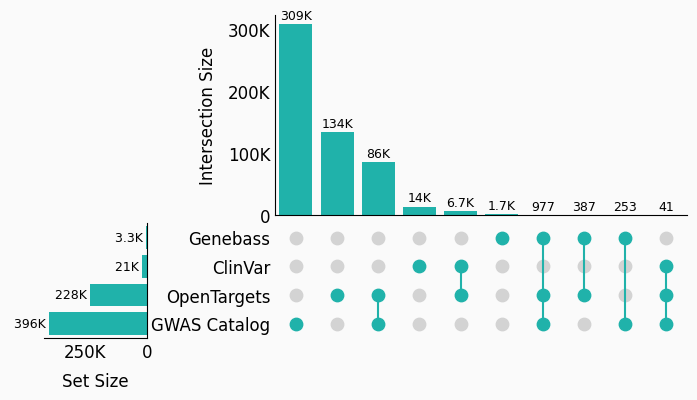

In [22]:
ge_all = pd.read_parquet(GE_COMBINED)
ge_upset = make_upset_df(ge_all, "source", n_intersections=10)
fig = plot_upset(ge_upset, wspace=0.5)
savefig(fig, "1b_ge_upset")

### UpSet: CT gene-drug sources

gene_drug_sources: showing 10 of 31 combinations, 107,301 rows (4.8%) not shown


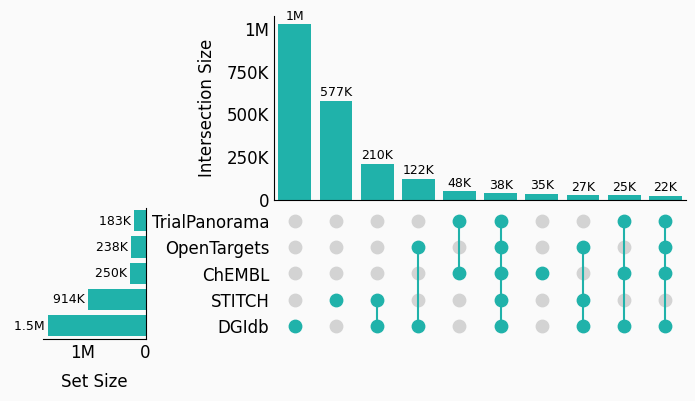

In [23]:
ct_all = pd.read_parquet(CLINICAL_TRIALS)
gd_upset = make_upset_df(ct_all, "gene_drug_sources", n_intersections=10)
fig = plot_upset(gd_upset, wspace=0.5)
savefig(fig, "s1_gd_upset")

### UpSet: CT drug-indication sources

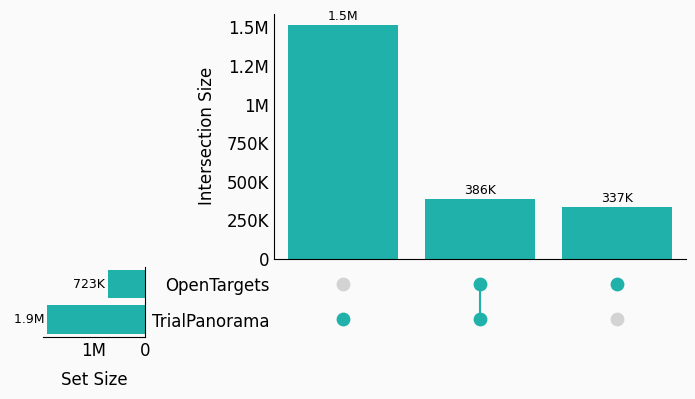

In [24]:
di_upset = make_upset_df(ct_all, "drug_indication_sources")
fig = plot_upset(di_upset, wspace=0.5)
savefig(fig, "s2_di_upset")

## 6. OpenTargets genetic evidence per subsource

OpenTargets genetic evidence by datasource, I→Approved against `ct_ot_only` (§2) — Open
Targets alone, so phases and censoring are that source's own.

`overall` pools every OpenTargets evidence type, including the `chembl` known-drug channel,
which encodes the outcome being predicted.

**Note:** This section requires raw Open Targets Platform 25.12 data
(`association_by_datasource_direct`, `association_overall_direct`, `known_drug`, `target`)
downloaded to `data/sources/opentargets/25.12/`.
See [DATA_SOURCES.md](../DATA_SOURCES.md) for download instructions.

In [25]:
# `ct_ot_only` is built in §2.
print(
    f"Open Targets only: {len(ct_ot_only):,} pairs, "
    f"{(ct_ot_only['max_phase'] == 4).mean():.1%} approved",
)

# Load all datasource associations and map ENSG -> gene symbol
ot_by_ds = pd.read_parquet(
    OT_DATA / "association_by_datasource_direct",
    columns=["datasourceId", "targetId", "diseaseId", "score"],
)
ot_targets = pd.read_parquet(OT_TARGET, columns=["id", "approvedSymbol"])
ensg_to_symbol = dict(zip(ot_targets["id"], ot_targets["approvedSymbol"]))
ot_by_ds["gene"] = ot_by_ds["targetId"].map(ensg_to_symbol)
ot_by_ds["efo_id"] = ot_by_ds["diseaseId"].str.replace("_", ":")
ot_by_ds = ot_by_ds[ot_by_ds["gene"].notna()]

# Also load overall associations
ot_overall = pd.read_parquet(
    OT_DATA / "association_overall_direct",
    columns=["targetId", "diseaseId", "score"],
)
ot_overall["gene"] = ot_overall["targetId"].map(ensg_to_symbol)
ot_overall["efo_id"] = ot_overall["diseaseId"].str.replace("_", ":")
ot_overall = ot_overall[ot_overall["gene"].notna()]

# --- 6a: Per-datasource at multiple score thresholds (each source filtered by its own score) ---
subsource_threshold_results = []
for threshold in [0, 0.25, 0.5, 0.75]:
    filtered = ot_by_ds[ot_by_ds["score"] >= threshold] if threshold > 0 else ot_by_ds
    overall_filtered = ot_overall[ot_overall["score"] >= threshold] if threshold > 0 else ot_overall

    experiments = {}
    for ds in sorted(filtered["datasourceId"].unique()):
        subset = filtered.loc[filtered["datasourceId"] == ds, ["gene", "efo_id"]].drop_duplicates()
        experiments[ds] = (subset, ct_ot_only)
    experiments["overall"] = (overall_filtered[["gene", "efo_id"]].drop_duplicates(), ct_ot_only)

    results = run_multi(experiments, label_col="subsource")
    results["threshold"] = threshold
    subsource_threshold_results.append(results)

ot_subsource_results = pd.concat(subsource_threshold_results, ignore_index=True)
ot_subsource_results.to_csv(OUTPUT / "ot_subsource_comparison.csv", index=False)

Open Targets only: 70,537 pairs, 8.8% approved


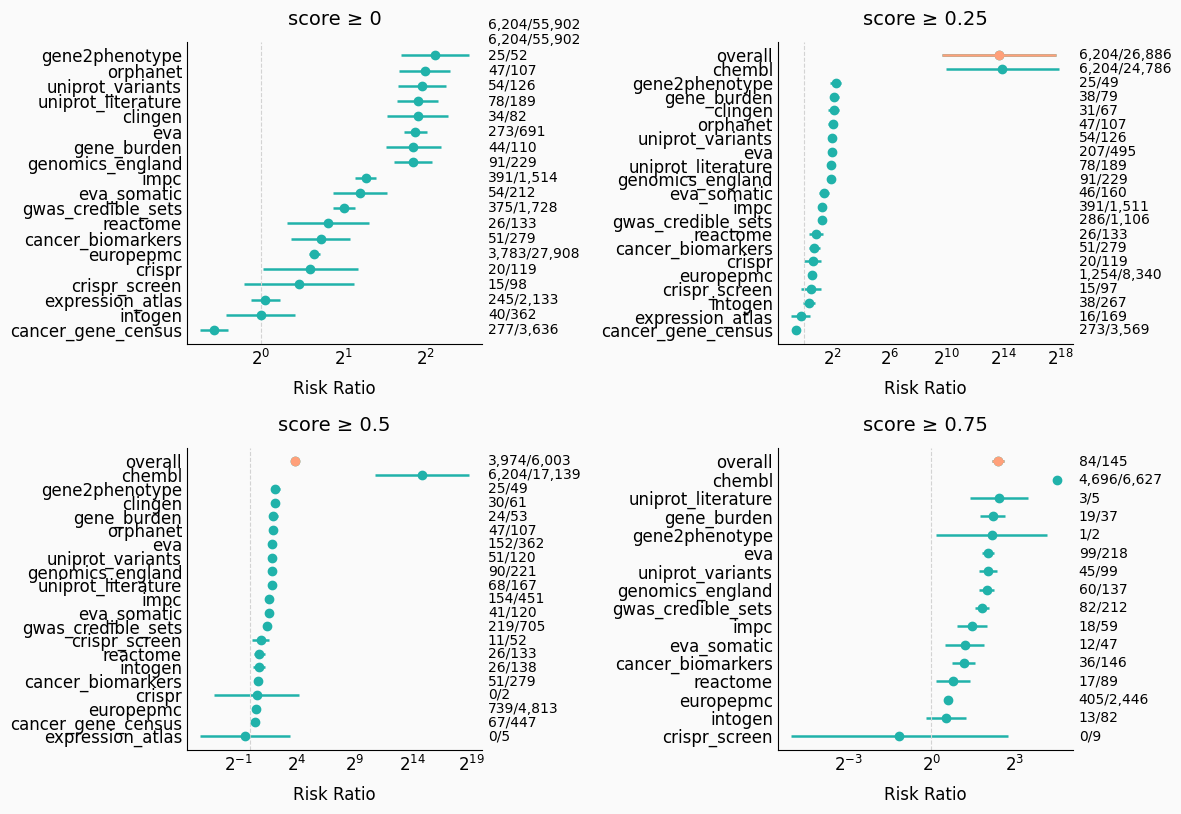

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8.3))
for ax, threshold in zip(axes.flatten(), [0, 0.25, 0.5, 0.75]):
    phase_df = ot_subsource_results[
        (ot_subsource_results["phase_label"] == "I→Approved")
        & (ot_subsource_results["threshold"] == threshold)
    ]
    # Drop empty results and sort by RR ascending, "overall" on top
    phase_df = phase_df[phase_df["n_yes"] > 0]
    phase_df = phase_df.sort_values("rr", ascending=True).reset_index(drop=True)
    non_overall = phase_df[phase_df["subsource"] != "overall"]
    overall_row = phase_df[phase_df["subsource"] == "overall"]
    phase_df = pd.concat([non_overall, overall_row], ignore_index=True)
    forest_plot(
        phase_df,
        "subsource",
        "I→Approved",
        title=f"score ≥ {threshold}",
        ax=ax,
        sort_order=phase_df["subsource"].tolist(),
    )
    # Highlight "overall" with second palette color
    labels = [t.get_text() for t in ax.get_yticklabels()]
    if "overall" in labels:
        c2 = plt.rcParams["axes.prop_cycle"].by_key()["color"][1]
        idx = labels.index("overall")
        row = overall_row.iloc[0]
        ax.errorbar(
            row["rr"],
            idx,
            xerr=[[row["rr"] - row["rr_ci_lower"]], [row["rr_ci_upper"] - row["rr"]]],
            fmt="o",
            color=c2,
            zorder=5,
        )
    ax.set_xscale("log", base=2)
fig.tight_layout()
savefig(fig, "s4_ot_subsources")

### 6b: Germline genetic OT datasources at different per-datasource score thresholds

In [27]:
# Mirrors GERMLINE_DATASOURCES in scripts/parse/genetic_evidence/opentargets.py so the
# max below matches the shipped parquet.
GERMLINE_DATASOURCES = {
    "gwas_credible_sets",
    "eva",
    "gene_burden",
    "genomics_england",
    "gene2phenotype",
    "clingen",
    "uniprot_variants",
    "uniprot_literature",
    "orphanet",
}

ot_genetic = ot_by_ds[ot_by_ds["datasourceId"].isin(GERMLINE_DATASOURCES)]

genetic_threshold_results = []
for threshold in [0, 0.25, 0.5, 0.75]:
    # Max score across genetic datasources per pair, then filter
    agg = (
        ot_genetic.groupby(["gene", "efo_id"], as_index=False)["score"]
        .max()
        .query(f"score >= {threshold}")
    )
    ge_pairs = agg[["gene", "efo_id"]].drop_duplicates()
    result = validate(clinical_trials=ct_ot_only, targets=ge_pairs, **VALIDATE_KWARGS)
    result["threshold"] = threshold
    result["n_pairs"] = len(ge_pairs)
    genetic_threshold_results.append(result)

genetic_results = pd.concat(genetic_threshold_results, ignore_index=True)
genetic_results.to_csv(OUTPUT / "ot_genetic_threshold_comparison.csv", index=False)

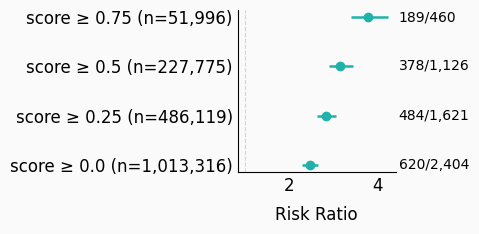

In [28]:
phase_df = genetic_results[genetic_results["phase_label"] == "I→Approved"]
fig, ax = plt.subplots(figsize=(5, 2.5))
forest_plot(
    phase_df.assign(
        label=lambda d: d["threshold"].map(
            lambda t: (
                f"score ≥ {t} (n={phase_df.loc[phase_df['threshold'] == t, 'n_pairs'].iloc[0]:,})"
            ),
        ),
    ),
    "label",
    "I→Approved",
    ax=ax,
)
fig.tight_layout()
savefig(fig, "s5_ot_genetic_thresholds")

## 7. Similarity-threshold sensitivity

The threshold decides how far from the evidence disease a clinical indication can sit
and still count as supported. The lookup only stores pairs at similarity >= 0.5, so that is
the floor.

The three arms are the diagonal of the 3x3 design: both legs from the same provider.

In [29]:
SIMILARITY_THRESHOLDS = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
SWEEP_ARMS = {
    "Minikel et al. GE × Citeline": (minikel_ge, minikel_ct),
    "Open Targets GE × Open Targets CT": (GE_OPENTARGETS, ct_ot_only),
    "Combined GE × Combined CT": (GE_COMBINED, CLINICAL_TRIALS),
}

sweep_results = []
for arm, (ge, ct) in SWEEP_ARMS.items():
    for threshold in SIMILARITY_THRESHOLDS:
        result = validate(
            clinical_trials=ct,
            targets=ge,
            similarity_threshold=threshold,
            **VALIDATE_KWARGS,
        )
        sweep_results.append(result.assign(experiment=arm, similarity_threshold=threshold))

similarity_sweep = pd.concat(sweep_results, ignore_index=True)
similarity_sweep.to_csv(OUTPUT / "similarity_threshold_sweep.csv", index=False)

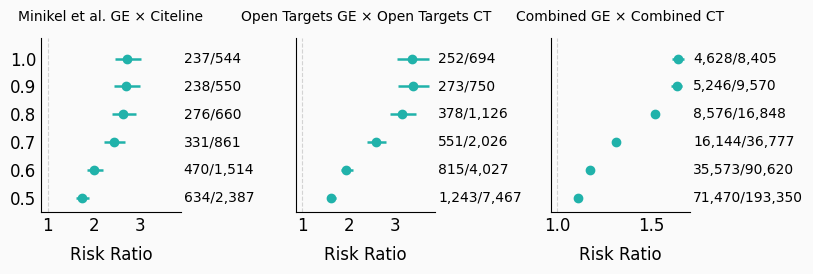

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(8.3, 2.9), sharey=True)
for ax, arm in zip(axes, SWEEP_ARMS):
    panel = similarity_sweep[similarity_sweep["experiment"] == arm].assign(
        label=lambda d: d["similarity_threshold"].astype(str),
    )
    # Pinned, not left to forest_plot's rr sort: the axes share a y-axis, so whichever panel
    # set its labels last would caption all three.
    forest_plot(
        panel,
        "label",
        "I→Approved",
        title=arm,
        ax=ax,
        sort_order=[str(t) for t in SIMILARITY_THRESHOLDS],
    )
    ax.set_title(arm, fontsize=10)
axes[0].sharex(axes[1])
axes[0].set_ylim(-0.5, axes[0].get_ylim()[1] + 0.5)
fig.tight_layout()
savefig(fig, "s6_similarity_thresholds")

## 8. Oncology stratification

Minikel et al. keep oncology; Tsepilov et al. exclude it. Two strata per arm: the full
table and the same table with oncology removed, not oncology against non-oncology.
Oncology is the `neoplasm` branch of EFO (EFO:0000616 and everything below it).

In [31]:
EFO_OBO = DATA / "mappings" / "efo_v3.84.0.obo"
NEOPLASM = "EFO:0000616"


def _obo_curie(raw: str) -> str:
    """Normalize an OBO identifier to the CURIE form used in our tables."""
    # EFO's own terms are written `efo:EFO_0000616`; imported terms are plain CURIEs.
    return raw.split(":", 1)[1].replace("_", ":") if raw.startswith("efo:") else raw


def load_efo_children(obo_path: Path) -> dict[str, list[str]]:
    """Map each term to its direct subclasses, from the is_a lines of an OBO file."""
    children = {}
    term_id = None
    for line in obo_path.read_text().splitlines():
        if line == "[Term]":
            term_id = None
        elif line.startswith("id: "):
            term_id = _obo_curie(line[4:].strip())
        elif line.startswith("is_a: ") and term_id:
            # `is_a: MONDO:0021143 {source="..."} ! melanocytic neoplasm` — the parent is
            # the first token; the trailing modifier and the ! comment both have to go.
            children.setdefault(_obo_curie(line[6:].split()[0]), []).append(term_id)
    return children


def descendants(children: dict[str, list[str]], root: str) -> set[str]:
    """Every term at or below `root`."""
    seen, stack = {root}, [root]
    while stack:
        for child in children.get(stack.pop(), []):
            if child not in seen:
                seen.add(child)
                stack.append(child)
    return seen


ONCOLOGY_TERMS = descendants(load_efo_children(EFO_OBO), NEOPLASM)
print(f"Oncology: {len(ONCOLOGY_TERMS):,} EFO terms below {NEOPLASM}")

oncology_results = []
for arm, (ge, ct) in SWEEP_ARMS.items():
    frame = pd.read_parquet(ct) if isinstance(ct, Path) else ct
    # Keys, not positions: the plot order below is built from these same labels.
    strata = {
        "with oncology": frame,
        "without oncology": frame[~frame["efo_id"].isin(ONCOLOGY_TERMS)],
    }
    for stratum, subset in strata.items():
        result = validate(clinical_trials=subset, targets=ge, **VALIDATE_KWARGS)
        oncology_results.append(result.assign(experiment=arm, stratum=stratum, pairs=len(subset)))

oncology_strata = pd.concat(oncology_results, ignore_index=True)
oncology_strata.to_csv(OUTPUT / "oncology_strata.csv", index=False)

Oncology: 3,331 EFO terms below EFO:0000616


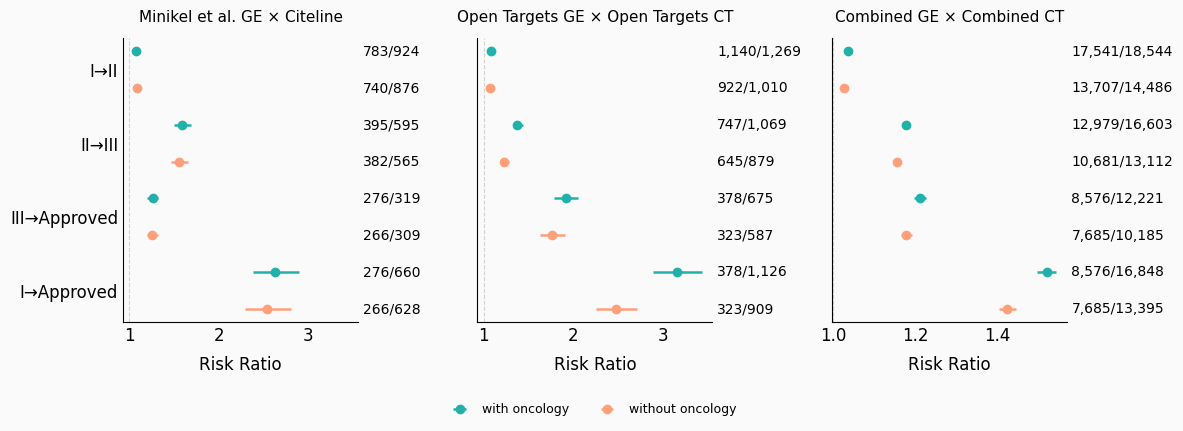

In [32]:
onc_plot = oncology_strata.assign(label=lambda d: d["phase_label"] + "  " + d["stratum"])

onc_order = [
    f"{phase}  {stratum}"
    for phase in PHASE_ORDER
    for stratum in oncology_strata["stratum"].unique()
]

fig, axes = plt.subplots(1, 3, figsize=(12, 4.0), sharey=True)
for ax, arm in zip(axes, SWEEP_ARMS):
    panel = onc_plot[onc_plot["experiment"] == arm]
    forest_plot(
        panel,
        "label",
        title=arm,
        ax=ax,
        color_col="stratum",
        sort_order=onc_order,
    )
    ax.set_title(arm, fontsize=11)
    # forest_plot draws one legend per axes; the figure carries a single one instead.
    ax.get_legend().remove()
axes[0].sharex(axes[1])

# One tick per transition, centred between its pair of strata.
axes[0].set_yticks([i + 0.5 for i in range(0, 2 * len(PHASE_ORDER), 2)])
axes[0].set_yticklabels(PHASE_ORDER)
axes[0].invert_yaxis()
fig.tight_layout()
fig.legend(
    *axes[0].get_legend_handles_labels(),
    loc="upper center",
    bbox_to_anchor=(0.5, 0.0),
    ncol=2,
    frameon=False,
)
savefig(fig, "s7_oncology_strata")

## 9. Prior-art configuration (Tsepilov et al. 2026)

Tsepilov et al. 2026, *The Human Pleiotropic Map of GWAS Associations and Therapeutic
Implications*, [doi:10.64898/2026.04.28.721048](https://doi.org/10.64898/2026.04.28.721048),
report risk ratios and odds ratios for the same question on Open Targets and ChEMBL. This
section runs our pipeline in their configuration.

Their Methods: target-indication pairs from the ChEMBL evidence source in Open Targets
25.06, drugs linked to targets by ChEMBL's curated mechanism of action, the maximal phase
per pair, entry at Phase I, "all oncology-related indications were excluded", Fisher's
exact test on approved (Phase IV) against not approved (Phases I-III), genetic evidence
"propagated through disease ontology" and matched to indications exactly, and no
censoring. The trial table below is the released `known_drug` aggregation of that same
evidence: 459 of 74,046 target-disease pairs carrying a ChEMBL association have no
`known_drug` row (0.6%), and no `known_drug` row lacks the association. We are on 25.12.

The comparison arm is one Open Targets datasource, `gwas_credible_sets`, from the
*indirect* release because they propagate. The rare-disease resources they also test
(Orphanet, OMIM, ClinVar/ClinGen, UniProt, Genomics England PanelApp) are scored as
separate categories, never pooled; our own two arms pool both. The ≥ 0.5 cut is the GE
parser's threshold used throughout this notebook, not their L2G cut, which applies inside
their credible-set pipeline rather than to the released harmonic-sum association score.

In [33]:
# `censor=False`: their construction reads every record as concluded and drops no status.
known_drug_ct = known_drug_pairs(censor=False)
# No `is_ongoing` on this table, so validate() censors nothing, as the prior art does not.
prior_art_ct = known_drug_ct[~known_drug_ct["efo_id"].isin(ONCOLOGY_TERMS)]

# Their Methods report the phase composition of the final table, which checks it directly.
phase_check = pd.DataFrame({"theirs": pd.Series({1: 6163, 2: 14410, 3: 12240, 4: 4564})})
phase_check["ours"] = prior_art_ct["max_phase"].value_counts()
phase_check["ratio"] = phase_check["ours"] / phase_check["theirs"]
print(phase_check.sort_index().to_string())


def gwas_credible_sets(min_score: float = 0.0) -> pd.DataFrame:
    """Their genetic support: the `gwas_credible_sets` datasource, propagated."""
    df = pd.read_parquet(
        OT_DATA / "association_by_datasource_indirect",
        columns=["datasourceId", "targetId", "diseaseId", "score"],
        filters=[("datasourceId", "==", "gwas_credible_sets")],
    )
    df = df[df["score"] >= min_score] if min_score else df
    df = df.assign(
        gene=df["targetId"].map(ensg_to_symbol),
        efo_id=df["diseaseId"].str.replace("_", ":", n=1),
    )
    return df[df["gene"].notna()][["gene", "efo_id"]].drop_duplicates()


PRIOR_ART_GE = {
    "GWAS credible sets, propagated ≥ 0.5": gwas_credible_sets(0.5),
    "OpenTargets GE, direct ≥ 0.5": GE_SOURCES["OpenTargets"],
    "Combined GE": GE_COMBINED,
}

prior_art_results = []
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=MissingOngoingWarning)
    for ge_kind, ge in PRIOR_ART_GE.items():
        # No similarity lookup: prior art matched indications exactly.
        result = validate(clinical_trials=prior_art_ct, targets=ge, gene_universe=GENE_UNIVERSE)
        prior_art_results.append(result.assign(targets=ge_kind))

prior_art = pd.concat(prior_art_results, ignore_index=True)
prior_art.to_csv(OUTPUT / "prior_art_configuration.csv", index=False)
print(f"\nPrior-art trial table: {len(prior_art_ct):,} target-indication pairs")
print(
    prior_art[prior_art["phase_label"] == "I→Approved"][
        [
            "targets",
            "x_yes",
            "n_yes",
            "rate_no",
            "rr",
            "rr_ci_lower",
            "rr_ci_upper",
            "or",
            "or_ci_lower",
            "or_ci_upper",
        ]
    ]
    .round(4)
    .to_string(index=False),
)

   theirs   ours     ratio
1    6163   6271  1.017524
2   14410  14615  1.014226
3   12240  12230  0.999183
4    4564   4501  0.986196

Prior-art trial table: 37,617 target-indication pairs
                             targets  x_yes  n_yes  rate_no     rr  rr_ci_lower  rr_ci_upper     or  or_ci_lower  or_ci_upper
GWAS credible sets, propagated ≥ 0.5    221    740   0.1160 2.5744       2.2971       2.8851 3.2448       2.7633       3.8102
        OpenTargets GE, direct ≥ 0.5    215    632   0.1158 2.9370       2.6253       3.2856 3.9356       3.3283       4.6539
                         Combined GE    256    786   0.1152 2.8273       2.5467       3.1388 3.7099       3.1849       4.3214


### Against the published figures

Their published cell is 242 of 742 supported pairs approved against 4,322 of 36,635
unsupported — RS 2.7645, OR 3.6186, drawn as the first row of each panel. They report
intervals only in a supplementary table stratified by therapeutic area, so the interval is
computed from their counts with the estimators used everywhere else here.

The rare-disease datasources they score as separate categories, for reference: ClinGen OR
5.1, UniProt 5.0, Genomics England PanelApp 4.5.

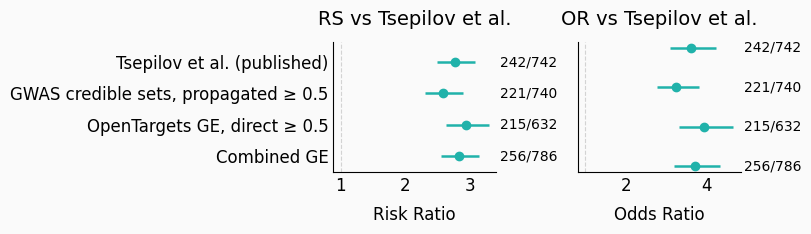

In [34]:
# Tsepilov et al. 2026, Methods: 37,377 T-I pairs of which 4,564 approved, 242 of them with
# GWAS support. x_no is 4,564 - 242; both are confirmed by solving their published RS and OR
# for the rates, which recovers 242.02 and 4,322.34.
PUBLISHED_COUNTS = (242, 742, 4322, 36635)  # x_yes, n_yes, x_no, n_no
PUBLISHED = {
    "rr": katz_ci_risk_ratio(*PUBLISHED_COUNTS),
    "or": woolf_ci_odds_ratio(*PUBLISHED_COUNTS),
}

PUBLISHED_LABEL = "Tsepilov et al. (published)"
# Their counts as one more row, so the published cell is read off the same axis as ours
# rather than against a reference line.
published_panel = pd.DataFrame(
    [
        {
            "label": PUBLISHED_LABEL,
            "phase_label": "I→Approved",
            **dict(zip(("x_yes", "n_yes", "x_no", "n_no"), PUBLISHED_COUNTS)),
            **{
                f"{metric}{suffix}": value
                for metric, values in PUBLISHED.items()
                for suffix, value in zip(("", "_ci_lower", "_ci_upper"), values)
            },
        },
    ],
)

comparison_panel = pd.concat(
    [
        published_panel,
        prior_art[prior_art["phase_label"] == "I→Approved"].assign(label=lambda d: d["targets"]),
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(8.3, 2.5))
for ax, metric in zip(axes, ["rr", "or"]):
    forest_plot(
        comparison_panel,
        "label",
        metric=metric,
        title=f"{'RS' if metric == 'rr' else 'OR'} vs Tsepilov et al.",
        ax=ax,
        sort_order=comparison_panel["label"].tolist()[::-1],
    )
axes[0].set_ylim(-0.5, axes[0].get_ylim()[1] + 0.5)
axes[1].set_yticklabels([])
fig.tight_layout()
savefig(fig, "s8_prior_art_comparison")